In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [20]:
import os
print("当前工作目录:", os.getcwd())
print("文件是否存在:", os.path.exists(r'ann_hb.xlsx'))

当前工作目录: C:\Users\yongh
文件是否存在: True


In [7]:
#处理table_1 预测flc

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import os

def load_data(file_path):
    """
    加载并预处理Excel数据，仅保留指定的6个输入列
    参数:
        file_path: Excel文件路径
    返回:
        pd.DataFrame: 处理后的数据表
    """
    try:
        # 读取原始数据
        raw_data = pd.read_excel(file_path, sheet_name='Table_1', header=None)
        print("原始数据形状:", raw_data.shape)
        
        # 检测标题行（查找包含'YS (Mpa)'的行）
        header_row = None
        for i in range(min(10, raw_data.shape[0])):
            if 'YS (Mpa)' in str(raw_data.iloc[i].values):
                header_row = i
                break
        
        if header_row is None:
            raise ValueError("未找到包含'YS (Mpa)'的标题行")
        
        print(f"检测到标题行: 第{header_row+1}行")
        
        # 正式读取数据
        table1 = pd.read_excel(
            file_path,
            sheet_name='Table_1',
            header=header_row
        )
        
        # 清理列名（统一大小写和空格）
        table1.columns = [str(col).strip().lower().replace(' ', '_') for col in table1.columns]
        print("处理后列名:", table1.columns.tolist())
        
        # 选择指定的6个输入列和输出列
        required_inputs = {
            'ys_(mpa)': 'ys_mpa',
            'uts_(mpa)': 'uts_mpa',
            'r': 'r',
            'epsilon_ul': 'epsilon_ul',
            'epsilon_t': 'epsilon_t',
            'n': 'n'
        }
        
        output_col = 'flc0'
        
        # 重命名并选择列
        table1 = table1.rename(columns=required_inputs)
        selected_cols = list(required_inputs.values()) + [output_col]
        table1 = table1[[col for col in selected_cols if col in table1.columns]]
        
        # 检查列是否齐全
        missing_cols = [col for col in selected_cols if col not in table1.columns]
        if missing_cols:
            raise ValueError(f"缺少必要列: {missing_cols}")
        
        # 删除包含缺失值的行
        table1 = table1.dropna()
        print("\n清洗后数据统计:")
        print(table1.describe().to_markdown(tablefmt="grid", floatfmt=".3f"))
        
        return table1
    
    except Exception as e:
        print(f"\n加载数据时出错: {str(e)}")
        print("\n调试建议:")
        print("1. 请确认Excel包含'Table_1'工作表")
        print("2. 检查是否包含以下列名: 'YS (Mpa)', 'UTS (Mpa)', 'r', 'epsilon_ul', 'epsilon_t', 'n'")
        print("3. 使用以下代码查看原始数据:")
        print(f"   pd.read_excel(r'{file_path}', sheet_name='Table_1', header=None).head(10)")
        raise

def train_model(data):
    """
    使用6个指定特征训练模型
    参数:
        data: 包含特征和目标值的数据框
    返回:
        model: 训练好的模型
        scaler: 特征缩放器
        data_with_pred: 包含预测结果的数据框
    """
    try:
        # 定义输入输出
        X = data[['ys_mpa', 'uts_mpa', 'r', 'epsilon_ul', 'epsilon_t', 'n']]
        y = data['flc0']
        
        # 数据预处理
        scaler = MinMaxScaler()
        X_scaled = scaler.fit_transform(X)
        
        # 分割数据集
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42
        )
        
        # 训练优化后的随机森林模型
        model = RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            min_samples_split=5,
            max_features=0.8,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)
        
        # 评估模型
        y_pred = model.predict(X_test)
        print("\n模型评估结果:")
        print(f"R²分数: {r2_score(y_test, y_pred):.4f}")
        print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
        
        # 特征重要性分析
        print("\n特征重要性:")
        for name, importance in zip(X.columns, model.feature_importances_):
            print(f"{name}: {importance:.3f}")
        
        # 对全部数据进行预测并添加到数据框中
        data_with_pred = data.copy()
        data_with_pred['flc_ho'] = model.predict(X_scaled)
        
        return model, scaler, data_with_pred
    
    except Exception as e:
        print(f"\n训练模型时出错: {str(e)}")
        raise

def main():
    # 文件路径设置（自动检测当前目录）
    current_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
    file_path = os.path.join(current_dir, 'ann_ho.xlsx')
    
    try:
        print(f"正在处理文件: {file_path}")
        
        # 1. 加载并预处理数据
        data = load_data(file_path)
        print("\n前5行数据:")
        print(data.head().to_markdown(tablefmt="grid", stralign='right'))
        
        # 2. 训练模型
        print("\n开始训练模型...")
        model, scaler, data_with_pred = train_model(data)
        
        # 输出包含预测结果的数据
        print("\n前5行数据(包含预测结果):")
        print(data_with_pred.head().to_markdown(tablefmt="grid", stralign='right'))
        
        # 3. 示例预测
        print("\n示例预测:")
        samples = [
            [195.4, 321.8, 1.19, 0.3, 0.387, 0.25],  # 示例1
            [245.0, 325.1, 1.01, 0.224, 0.313, 0.17], # 示例2
            [223.8, 303.4, 1.56, 0.259, 0.389, 0.21]  # 示例3
        ]
        
        for i, sample in enumerate(samples, 1):
            scaled_sample = scaler.transform([sample])
            prediction = model.predict(scaled_sample)[0]
            print(f"样本{i}: 预测值 = {prediction:.4f}")
            print(f"  输入值: YS={sample[0]} MPa, UTS={sample[1]} MPa, r={sample[2]}")
            print(f"          ε_ul={sample[3]}, ε_t={sample[4]}, n={sample[5]}\n")
            
        # 保存包含预测结果的数据到新文件
        output_path = os.path.join(current_dir, 'ann_ho_with_predictions.xlsx')
        data_with_pred.to_excel(output_path, index=False)
        print(f"\n预测结果已保存到: {output_path}")
            
    except Exception as e:
        print(f"\n程序运行出错: {str(e)}")

if __name__ == "__main__":
    main()

正在处理文件: C:\Users\yongh\ann_ho.xlsx
原始数据形状: (133, 16)
检测到标题行: 第4行
处理后列名: ['unnamed:_0', 'ref.', 'steels', 'unnamed:_3', 't_(mm)', 'ys_(mpa)', 'uts_(mpa)', 'r', 'epsilon_ul', 'epsilon_t', 'n', 'flc0', 'flc0,_paul', 'flc0__kb', 'unnamed:_14', 'flc0_ann']

清洗后数据统计:
+-------+----------+-----------+---------+--------------+-------------+---------+---------+
|       |   ys_mpa |   uts_mpa |       r |   epsilon_ul |   epsilon_t |       n |    flc0 |
+=======+==========+===========+=========+==============+=============+=========+=========+
| count |  129.000 |   129.000 | 129.000 |      129.000 |     129.000 | 129.000 | 129.000 |
+-------+----------+-----------+---------+--------------+-------------+---------+---------+
| mean  |  438.337 |   566.916 |   1.001 |        5.492 |       0.291 |   0.143 |   0.324 |
+-------+----------+-----------+---------+--------------+-------------+---------+---------+
| std   |  183.543 |   188.121 |   0.313 |        9.295 |       0.092 |   0.070 |   0.079 |
+-

C:\Users\yongh\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\yongh\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\yongh\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [17]:
#处理table_2 预测p
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import os

def load_data(file_path):
    """
    加载并预处理Excel数据，仅保留指定的6个输入列
    参数:
        file_path: Excel文件路径
    返回:
        pd.DataFrame: 处理后的数据表
    """
    try:
        # 读取原始数据
        raw_data = pd.read_excel(file_path, sheet_name='Table_2', header=None)
        print("原始数据形状:", raw_data.shape)
        
        # 检测标题行（查找包含'YS (Mpa)'的行）
        header_row = None
        for i in range(min(10, raw_data.shape[0])):
            if 'YS (Mpa)' in str(raw_data.iloc[i].values):
                header_row = i
                break
        
        if header_row is None:
            raise ValueError("未找到包含'YS (Mpa)'的标题行")
        
        print(f"检测到标题行: 第{header_row+1}行")
        
        # 正式读取数据
        table2 = pd.read_excel(
            file_path,
            sheet_name='Table_2',
            header=header_row
        )
        
        # 清理列名（统一大小写和空格）
        table2.columns = [str(col).strip().lower().replace(' ', '_') for col in table2.columns]
        print("处理后列名:", table2.columns.tolist())
        
        # 选择指定的6个输入列和输出列
        required_inputs = {
            't_(mm)': 't_(mm)',
            'uts_(mpa)': 'uts_mpa',
            'r': 'r',
            'flc0': 'flc0',
            'epsilon_t': 'epsilon_t',
            'n': 'n'
        }
        
        output_col = 'p,_exp'
        
        # 重命名并选择列
        table2 = table2.rename(columns=required_inputs)
        selected_cols = list(required_inputs.values()) + [output_col]
        table2 = table2[[col for col in selected_cols if col in table2.columns]]
        
        # 检查列是否齐全
        missing_cols = [col for col in selected_cols if col not in table2.columns]
        if missing_cols:
            raise ValueError(f"缺少必要列: {missing_cols}")
        
        # 删除包含缺失值的行
        table2 = table2.dropna()
        print("\n清洗后数据统计:")
        print(table2.describe().to_markdown(tablefmt="grid", floatfmt=".3f"))
        
        return table2
    
    except Exception as e:
        print(f"\n加载数据时出错: {str(e)}")
        print("\n调试建议:")
        print("1. 请确认Excel包含'Table_2'工作表")
        print("2. 检查是否包含以下列名: 't_(mm)', 'UTS (Mpa)', 'r', 'flc0', 'epsilon_t', 'n'")
        print("3. 使用以下代码查看原始数据:")
        print(f"   pd.read_excel(r'{file_path}', sheet_name='Table_2', header=None).head(10)")
        raise

def train_model(data):
    """
    使用6个指定特征训练模型
    参数:
        data: 包含特征和目标值的数据框
    返回:
        model: 训练好的模型
        scaler: 特征缩放器
        data_with_pred: 包含预测结果的数据框
    """
    try:
        # 定义输入输出
        X = data[['t_(mm)', 'uts_mpa', 'r', 'flc0', 'epsilon_t', 'n']]
        y = data['p,_exp']
        
        # 数据预处理
        scaler = MinMaxScaler()
        X_scaled = scaler.fit_transform(X)
        
        # 分割数据集
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42
        )
        
        # 训练优化后的随机森林模型
        model = RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            min_samples_split=5,
            max_features=0.8,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)
        
        # 评估模型
        y_pred = model.predict(X_test)
        print("\n模型评估结果:")
        print(f"R²分数: {r2_score(y_test, y_pred):.4f}")
        print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
        
        # 特征重要性分析
        print("\n特征重要性:")
        for name, importance in zip(X.columns, model.feature_importances_):
            print(f"{name}: {importance:.3f}")
        
        # 对全部数据进行预测并添加到数据框中
        data_with_pred = data.copy()
        data_with_pred['p_ho'] = model.predict(X_scaled)
        
        return model, scaler, data_with_pred
    
    except Exception as e:
        print(f"\n训练模型时出错: {str(e)}")
        raise

def main():
    # 文件路径设置（自动检测当前目录）
    current_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
    file_path = os.path.join(current_dir, 'ann_ho.xlsx')
    
    try:
        print(f"正在处理文件: {file_path}")
        
        # 1. 加载并预处理数据
        data = load_data(file_path)
        print("\n前5行数据:")
        print(data.head().to_markdown(tablefmt="grid", stralign='right'))
        
        # 2. 训练模型
        print("\n开始训练模型...")
        model, scaler, data_with_pred = train_model(data)
        
        # 输出包含预测结果的数据
        print("\n前5行数据(包含预测结果):")
        print(data_with_pred.head().to_markdown(tablefmt="grid", stralign='right'))
        
        # 3. 示例预测
        print("\n示例预测:")
        samples = [
            [195.4, 321.8, 1.19, 0.3, 0.387, 0.25],  # 示例1
            [245.0, 325.1, 1.01, 0.224, 0.313, 0.17], # 示例2
            [223.8, 303.4, 1.56, 0.259, 0.389, 0.21]  # 示例3
        ]
        
        for i, sample in enumerate(samples, 1):
            scaled_sample = scaler.transform([sample])
            prediction = model.predict(scaled_sample)[0]
            print(f"样本{i}: 预测值 = {prediction:.4f}")
            print(f"  输入值: YS={sample[0]} MPa, UTS={sample[1]} MPa, r={sample[2]}")
            print(f"          ε_ul={sample[3]}, ε_t={sample[4]}, n={sample[5]}\n")
            
        # 保存包含预测结果的数据到新文件
        output_path = os.path.join(current_dir, 'ann_ho_with_predictions_p.xlsx')
        data_with_pred.to_excel(output_path, index=False)
        print(f"\n预测结果已保存到: {output_path}")
            
    except Exception as e:
        print(f"\n程序运行出错: {str(e)}")

if __name__ == "__main__":
    main()

正在处理文件: C:\Users\yongh\ann_ho.xlsx
原始数据形状: (26, 17)
检测到标题行: 第4行
处理后列名: ['unnamed:_0', 'ref.', 'steels', 'unnamed:_3', 't_(mm)', 'ys_(mpa)', 'uts_(mpa)', 'r', 'epsilon_ul', 'epsilon_t', 'n', 'flc0', 'flc0,_ann', 'p,_paul', 'p,_exp', 'unnamed:_15', 'p,_ann']

清洗后数据统计:
+-------+----------+-----------+--------+--------+-------------+--------+----------+
|       |   t_(mm) |   uts_mpa |      r |   flc0 |   epsilon_t |      n |   p,_exp |
+=======+==========+===========+========+========+=============+========+==========+
| count |   22.000 |    22.000 | 22.000 | 22.000 |      22.000 | 22.000 |   22.000 |
+-------+----------+-----------+--------+--------+-------------+--------+----------+
| mean  |    1.705 |   537.959 |  1.100 |  0.340 |       0.315 |  0.188 |    0.358 |
+-------+----------+-----------+--------+--------+-------------+--------+----------+
| std   |    0.881 |   243.615 |  0.362 |  0.108 |       0.133 |  0.113 |    0.114 |
+-------+----------+-----------+--------+--------+---

C:\Users\yongh\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\yongh\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\yongh\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [23]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


正在处理文件: C:\Users\yongh\ann_ho_with_predictions.xlsx


C:\Users\yongh\AppData\Local\Temp\ipykernel_7300\671025472.py:63: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) Arial.
  plt.savefig(output_path, dpi=300, bbox_inches='tight')
C:\Users\yongh\AppData\Local\Temp\ipykernel_7300\671025472.py:63: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) Arial.
  plt.savefig(output_path, dpi=300, bbox_inches='tight')
C:\Users\yongh\AppData\Local\Temp\ipykernel_7300\671025472.py:63: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) Arial.
  plt.savefig(output_path, dpi=300, bbox_inches='tight')
C:\Users\yongh\AppData\Local\Temp\ipykernel_7300\671025472.py:63: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(output_path, dpi=300, bbox_inches='tight')
C:\Users\yongh\AppData\Local\Temp\ipykernel_7300\671025472.py:63: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) Arial.
  plt.savefig(output_path


图形已保存到: C:\Users\yongh\flc_prediction_comparison.png


C:\Users\yongh\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\yongh\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\yongh\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\yongh\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\yongh\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw

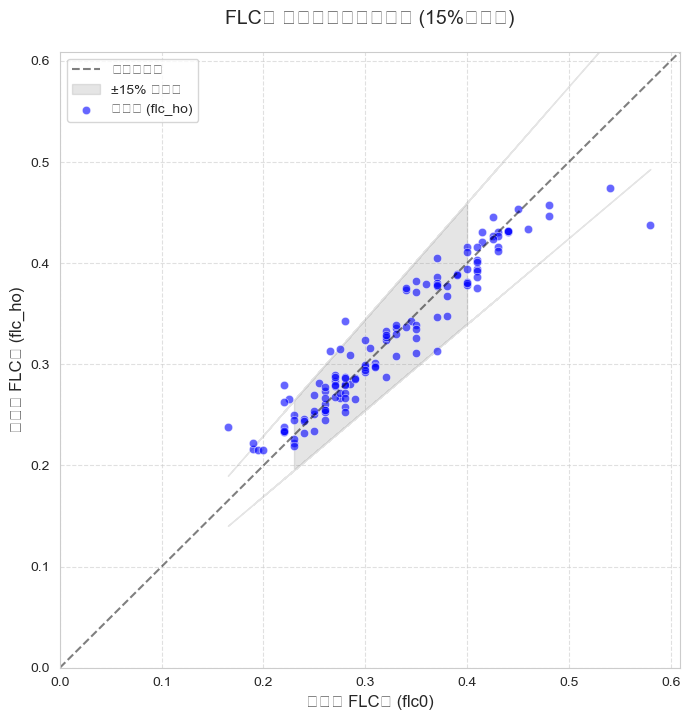

In [27]:
#绘制PLC与预测值之间的关系
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
def plot_flc_comparison(file_path):
    """
    绘制FLC预测结果对比图，包含15%误差带
    
    参数:
        file_path: 包含预测结果的Excel文件路径
    """
    try:
        # 读取数据
        data = pd.read_excel(file_path)
        
        # 检查必要的列是否存在
        required_cols = ['flc0', 'flc_ho']
        missing_cols = [col for col in required_cols if col not in data.columns]
        if missing_cols:
            raise ValueError(f"数据文件中缺少必要列: {missing_cols}")
        
        # 准备绘图数据
        x = data['flc0']
        y = data['flc_ho']
        
        # 创建图形
        plt.figure(figsize=(8, 8))
        
        sns.set_style("whitegrid")
        # 绘制45度参考线
        max_val = max(max(x), max(y)) * 1.05
        plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='理想预测线')
        
        # 绘制15%误差带
        error_percent = 0.15
        upper_bound = x * (1 + error_percent)
        lower_bound = x * (1 - error_percent)
        plt.fill_between(x, lower_bound, upper_bound, color='gray', alpha=0.2, 
                         label=f'±{error_percent*100:.0f}% 误差带')
        
        # 绘制散点图
        scatter = plt.scatter(x, y, c='blue', alpha=0.6, edgecolors='w', linewidth=0.5, 
                             label='预测值 (flc_ho)')
        
        # 添加图例和标签
        plt.legend(loc='upper left')
        plt.xlabel('实验值 FLC₀ (flc0)', fontsize=12)
        plt.ylabel('预测值 FLC₀ (flc_ho)', fontsize=12)
        plt.title('FLC₀ 预测值与实验值对比 (15%误差带)', fontsize=14, pad=20)
        
        # 设置坐标轴范围
        plt.xlim(0, max_val)
        plt.ylim(0, max_val)
        
        # 添加网格
        plt.grid(True, linestyle='--', alpha=0.6)
        
        # 保存图形
        output_dir = os.path.dirname(file_path)
        output_path = os.path.join(output_dir, 'flc_prediction_comparison.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"\n图形已保存到: {output_path}")
        
        # 显示图形
        plt.show()
        
    except Exception as e:
        print(f"\n绘制图形时出错: {str(e)}")
        raise

def main():
    # 文件路径设置（自动检测当前目录）
    current_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
    file_path = os.path.join(current_dir, 'ann_ho_with_predictions.xlsx')
    
    try:
        print(f"正在处理文件: {file_path}")
        plot_flc_comparison(file_path)
    except Exception as e:
        print(f"\n程序运行出错: {str(e)}")

if __name__ == "__main__":
    main()

正在处理文件: C:\Users\yongh\ann_ho_with_predictions_p.xlsx
使用seaborn样式


C:\Users\yongh\AppData\Local\Temp\ipykernel_7300\2436852463.py:76: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) Arial.
  plt.savefig(output_path, dpi=300, bbox_inches='tight')
C:\Users\yongh\AppData\Local\Temp\ipykernel_7300\2436852463.py:76: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) Arial.
  plt.savefig(output_path, dpi=300, bbox_inches='tight')
C:\Users\yongh\AppData\Local\Temp\ipykernel_7300\2436852463.py:76: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) Arial.
  plt.savefig(output_path, dpi=300, bbox_inches='tight')
C:\Users\yongh\AppData\Local\Temp\ipykernel_7300\2436852463.py:76: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) Arial.
  plt.savefig(output_path, dpi=300, bbox_inches='tight')
C:\Users\yongh\AppData\Local\Temp\ipykernel_7300\2436852463.py:76: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) Arial.
  plt.s


图形已保存到: C:\Users\yongh\ann_ho_with_predictions_p.png


C:\Users\yongh\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\yongh\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\yongh\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\yongh\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\yongh\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) Arial.
  fig.canvas.print_figure(b

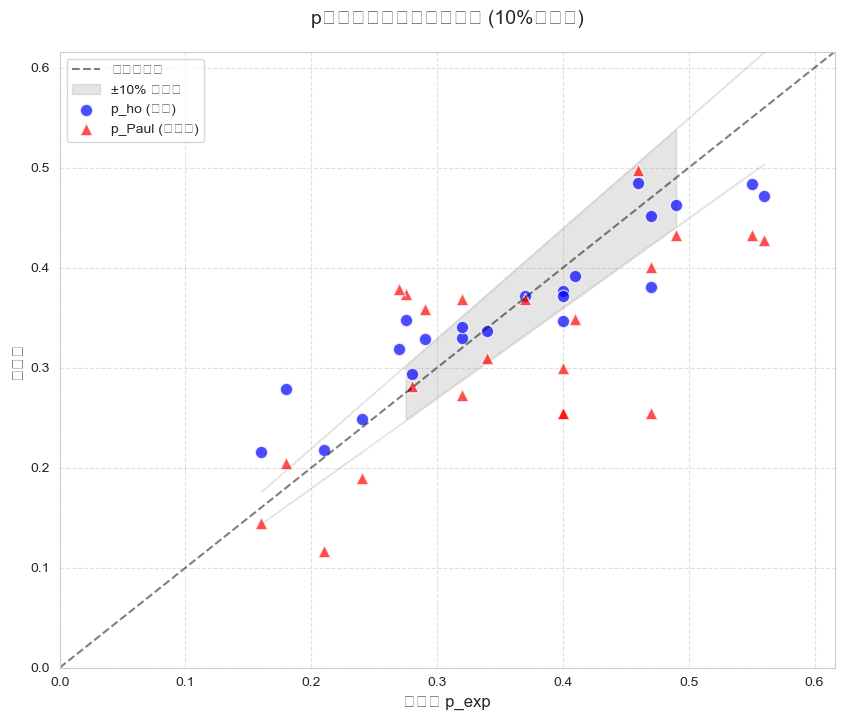

In [33]:
#绘制p的预测图
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_p_comparison(file_path):
    """
    绘制p参数对比图，包含10%误差带
    
    参数:
        file_path: 包含预测结果的Excel文件路径
    """
    try:
        # 读取数据
        data = pd.read_excel(file_path)
        
        # 检查必要的列是否存在
        required_cols = ['p,_exp', 'p_ho', 'p, Paul']
        missing_cols = [col for col in required_cols if col not in data.columns]
        if missing_cols:
            raise ValueError(f"数据文件中缺少必要列: {missing_cols}")
        
        # 准备绘图数据
        x = data['p,_exp']
        y_ho = data['p_ho']
        y_paul = data['p, Paul']
        
        # 创建图形
        plt.figure(figsize=(10, 8))
        
        # 使用seaborn样式(如果可用)，否则使用ggplot
        try:
            import seaborn as sns
            sns.set_style("whitegrid")
            print("使用seaborn样式")
        except ImportError:
            plt.style.use('ggplot')
            print("使用Matplotlib ggplot样式")
        
        # 绘制45度参考线
        max_val = max(max(x), max(y_ho), max(y_paul)) * 1.1
        plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='理想预测线')
        
        # 绘制10%误差带
        error_percent = 0.10
        upper_bound = x * (1 + error_percent)
        lower_bound = x * (1 - error_percent)
        plt.fill_between(x, lower_bound, upper_bound, color='gray', alpha=0.2, 
                         label=f'±{error_percent*100:.0f}% 误差带')
        
        # 绘制散点图 - p_ho用圆形标注
        plt.scatter(x, y_ho, c='blue', marker='o', s=80, alpha=0.7, 
                   edgecolors='w', linewidth=1, label='p_ho (圆形)')
        
        # 绘制散点图 - p_Paul用三角形标注
        plt.scatter(x, y_paul, c='red', marker='^', s=80, alpha=0.7, 
                   edgecolors='w', linewidth=1, label='p_Paul (三角形)')
        
        # 添加图例和标签
        plt.legend(loc='upper left', fontsize=10)
        plt.xlabel('实验值 p_exp', fontsize=12)
        plt.ylabel('预测值', fontsize=12)
        plt.title('p参数预测值与实验值对比 (10%误差带)', fontsize=14, pad=20)
        
        # 设置坐标轴范围
        plt.xlim(0, max_val)
        plt.ylim(0, max_val)
        
        # 添加网格
        plt.grid(True, linestyle='--', alpha=0.6)
        
        # 保存图形
        output_dir = os.path.dirname(file_path)
        output_path = os.path.join(output_dir, 'ann_ho_with_predictions_p.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"\n图形已保存到: {output_path}")
        
        # 显示图形
        plt.show()
        
    except Exception as e:
        print(f"\n绘制图形时出错: {str(e)}")
        raise

def main():
    # 文件路径设置（自动检测当前目录）
    current_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
    file_path = os.path.join(current_dir, 'ann_ho_with_predictions_p.xlsx')
    
    try:
        print(f"正在处理文件: {file_path}")
        plot_p_comparison(file_path)
    except Exception as e:
        print(f"\n程序运行出错: {str(e)}")

if __name__ == "__main__":
    main()